Key point:

preprocessing:

- boolean type:
    - False -> 0; True -> 1
- categories:
    - orbital_period_cat & dist_category: transform to ordinal based on number(period length/distance) itself
    - others: combine those occur less than 50 times to a catogory 'Other', then one-hot encoding is applied

3 models:
- SVC with default parameters
- SMOTE + SVC with default parameters
- grid search + SVC, optimized with F1 score (improve precision rate at the cost of recall rate)

performance:




| Model                               |  Threshold | Accuracy | Precision | Recall | F1 Score |    ROC-AUC | Avg Precision |
|-------------------------------------|-----------:|-----------:|----------:|-------:|---------:|-----------:|------------:|
| **Model 1 – Baseline**              |          0 | 0.9047 | 0.4294 | **0.9620** | 0.5938 |     0.9719 |        0.7573 |
| +Val Threshold                      |     0.5753 | 0.9432 | 0.5780 | 0.7975 | 0.6702 |            |             |
| +Val Threshold & Recall > 0.85      |     0.3193 | 0.9294 | 0.5074 | 0.8734 | 0.6419 |            |             |
| **Model 2 – SMOTE**                 |          0 | 0.9193 | 0.4710 | 0.9241 | 0.6239 |     0.9726 |        0.7660 |
| +Val Threshold                      |     0.3991 | 0.9432 | 0.5780 | 0.7975 | 0.6702 |            |             |
| +Val Threshold & Recall > 0.85      |     0.1812 | 0.9340 | 0.5267 | 0.8734 | 0.6571 |            |             |
| 🔴**Model 3 – Grid Search + SMOTE** |          0 | 0.9386 | 0.5476 | 0.8734 | 0.6732 | **0.9742** |    **0.7780** |
| +Val Threshold                      |    0.63443 | **0.9578** | **0.7391** | 0.6456 | **0.6892** |            |            |
| +Val Threshold & Recall > 0.85       |     0.0013 | 0.9386 | 0.5476 | 0.8734 | 0.6731 |            |         |



based on the permutation importance, orbital period, semi major axis, star_vmag and star temperature are effective indicators.

AUC is around 97% for three models


further improvement
- threshold tuning to find a threshold that maximize f1 score or satisfies a recall >90% constraint.


Interpretation:

To begin with, we identify raw features span three types: numerical, boolean and categorical variables. In order to fully utilize all of them, transformation is required. Boolean flags are converted to 0/1. Ordered categories are mapped to integers preserving their inherent ranking. For the remaining categories, rare classes are combined to reduce dimensionality, and then one-hot encoding is applied.

Considering the target is highly imbalanced, only about 7% of samples are positive. All three SVC models apply "class-weight  = balanced" to adjust decision boundary.

A default rbf-kernal svc serves as benchmark: accuracy 90.5%, recall 96.2%, but precision only 42.9% (F1 = 0.594). Model 1 correctly identifies most positives, but generates many false.

We then apply SMOTE, a technique synthetically generate minority class samples, to help model learn more discriminative information from the positive class. After application of SMOTE, Model2 achieves improvement on precision (by 4%), f1 score (3%), while recall rate drops to 92.4%


However, SMOTE alone does not optimise the decision enough. The SVC kernel, regularisation strength, and SMOTE parameters all interact and must be tuned jointly.  We apply grid search in Model 3, scoring by f1 score to directly optimise the precision–recall trade-off. The best configuration (C=5, kernel=rbf, gamma=auto) achieves precision 55%, recall 87% and f1 0.67.

We apply threshold tuning to these three models, maximizing f1 score. For the unrestricted condition, f1 score improves in the range of 2% to 8% at the enormous cost at recall rate(approximately 20%). Therefore, we add constraint of recall rate > 85% to it.

Model 3 provides the most balanced performance across all metrics, therefore it is selected as the best model. Besides, model 3 performs best among all the tuned models with high recall rate(>85%).

Finally, through the comparison of permutation importance along three model, four features consistently dominate: orbital period, semi-major axis, stellar visual magnitude, and stellar temperature. These features are physically explainable, measuring planet energy and orbital geometry. This allignment lends credibility to the model's learned behaviour.


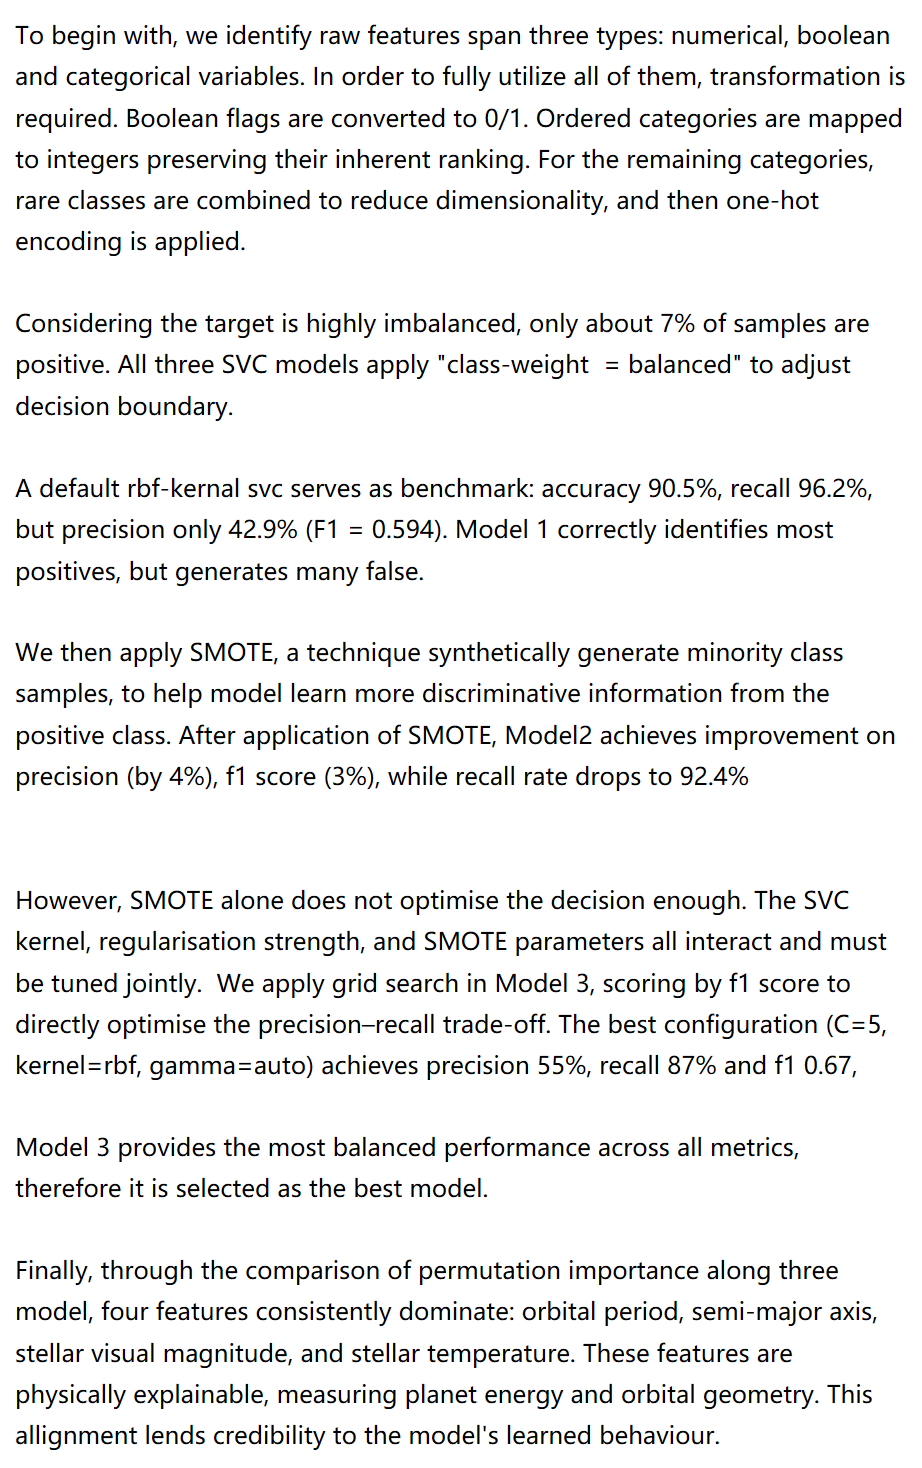

# 1.load data

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_cleaned = pd.read_csv('exoplanet_clean.csv')
df = df_cleaned.copy()

# 2.data preprocessing
convert categories/boolean to int, get data ready for modelling

In [2]:
num_cols = ['orbital_period_days', 'planet_radius_earth', 'planet_mass_earth',
            'semi_major_axis_au', 'star_temp_k', 'star_radius_sun',
            'star_mass_sun', 'star_surface_gravity', 'star_metallicity',
            'star_vmag', 'dist_from_earth_pc']
bool_cols = ['habitable_zone_flag','multi_planet_system','is_recent_discovery']
cat_cols = ['planet_type','star_type','discovery_method','dist_category',
            'orbital_period_cat']

In [3]:
for cat in cat_cols:
    print(df[cat].value_counts(),'\n')

planet_type
Mini-Neptune     1987
Gas Giant        1419
Super-Earth      1082
Neptune-like      418
Super-Jupiter     294
Sub-Earth         215
Unknown            36
Name: count, dtype: int64 

star_type
G-type(Sun-like)     2515
K-type               1521
F-type               1036
M-type(Red Dwarf)     353
A-type                 19
B-type                  5
O-type                  2
Name: count, dtype: int64 

discovery_method
Transit                          4258
Radial Velocity                  1129
Transit Timing Variations          34
Imaging                            17
Eclipse Timing Variations           6
Orbital Brightness Modulation       3
Astrometry                          3
Pulsation Timing Variations         1
Name: count, dtype: int64 

dist_category
Far(500-2kpc)     2178
Mid(100-500pc)    1790
Nearby(<100pc)    1405
Distant(2k+pc)      63
Unknown             15
Name: count, dtype: int64 

orbital_period_cat
Short(1-10d)        2429
Medium(10-100d)     1964
Very-Long(3

In [4]:
# categories with clear order
dist_order = {
    'Nearby(<100pc)': 0,
    'Mid(100-500pc)': 1,
    'Far(500-2kpc)': 2,
    'Distant(2k+pc)':3,
    'Unknown': 1    # map 'Unknown' distance to 1 (Mid-range) as a conservative median assumption;
}
df['dist_category'] = df['dist_category'].map(dist_order)

period_order = {
    'Ultra-Short(<1d)': 0,
    'Short(1-10d)': 1,
    'Medium(10-100d)': 2,
    'Long(100-365d)': 3,
    'Very-Long(365d+)': 4,
}
df['orbital_period_cat'] = df['orbital_period_cat'].map(period_order)

In [5]:
# define 'True' as 1, 'False' as 0 to the columns with boolean type
df[bool_cols] = df[bool_cols].astype(int)

In [6]:
# for the rest columns, we combine the categories occurs less than 50 times, and apply one-hot encoding
one_hot_cols = ['planet_type', 'star_type', 'discovery_method']

for col in one_hot_cols:
    cur_col = df[col]
    combined_cat = cur_col.value_counts()[lambda x: x<50].index
    cur_col = cur_col.replace(combined_cat, 'Other')
    dummies = pd.get_dummies(cur_col, prefix = col).astype(int)
    df = pd.concat([df, dummies], axis = 1)

df = df.drop(columns = one_hot_cols)

In [7]:
for col in one_hot_cols:
    print(df.filter(regex=col).sum(), '\n')
print(df.info())
# all the data type is int64/float64

planet_type_Gas Giant        1419
planet_type_Mini-Neptune     1987
planet_type_Neptune-like      418
planet_type_Other              36
planet_type_Sub-Earth         215
planet_type_Super-Earth      1082
planet_type_Super-Jupiter     294
dtype: int64 

star_type_F-type               1036
star_type_G-type(Sun-like)     2515
star_type_K-type               1521
star_type_M-type(Red Dwarf)     353
star_type_Other                  26
dtype: int64 

discovery_method_Other                64
discovery_method_Radial Velocity    1129
discovery_method_Transit            4258
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   n_stars                           5451 non-null   int64  
 1   n_planets                         5451 non-null   int64  
 2   orbital_period_days               5451 non-null   

In [8]:
# Snapshot of encoded DataFrame before feature engineering
df_intact = df.copy()

# 3.feature engineering

In [9]:
# I just copy the feature engineering coding and paste it here

# transform family
# applying log transformations
log_cols = ['orbital_period_days', 'planet_mass_earth', 'semi_major_axis_au', 'dist_from_earth_pc']

for col in log_cols:
    df[f'log_{col}'] = np.log10(df[col] + 1e-6)
# ratio family
# density
df['planet_density_proxy'] = df['planet_mass_earth'] / (df['planet_radius_earth'] ** 3)

# Flux
# Formula: (Star Temperature / Sun Temp)^4 * (Star Radius)^2 / (Distance)^2
df['stellar_flux'] = ((df['star_temp_k'] / 5778) ** 4 * (df['star_radius_sun'] ** 2)) / (df['semi_major_axis_au'] ** 2)

# Relative Distance
df['rel_dist_to_star_mass'] = df['semi_major_axis_au'] / df['star_mass_sun']


# drop the features that are highly correlated to others
drop_cols = ['planet_mass_earth', 'semi_major_axis_au', 'star_mass_sun',
             'star_surface_gravity']
df = df.drop(columns = drop_cols)

# 4. data split
80% train(+validation) set, 20% test set

In [10]:
from sklearn.model_selection import train_test_split


X = df.drop(columns = ['habitable_zone_flag'])
y = df['habitable_zone_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4360, 35) (1091, 35) (4360,) (1091,)


# 5. define model construction and evaluation function

In [11]:
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import confusion_matrix, roc_auc_score


def svc_model(X_train, X_test, y_train, kernel = 'rbf', C = 1):
    # class_weight = 'balanced' adjusts weights inversely proportional to class frequency
    svc = SVC(kernel = kernel, C = C, class_weight= 'balanced', random_state=42)
    svc.fit(X_train,y_train)
    y_pred = svc.predict(X_test)
    y_score = svc.decision_function(X_test)
    return y_pred, y_score, svc

In [39]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

def compute_performance(y_true, y_pred, y_score):
    fig, axes = plt.subplots(1, 3, figsize = (16, 4))

    confusion_mat = confusion_matrix(y_true,y_pred)
    sns.heatmap(confusion_mat, fmt = 'd', annot = True, cmap='Blues',
                xticklabels=['0', '1'], yticklabels=['0', '1'], ax = axes[0])
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')
    axes[0].set_title('Confusion matrix')

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label = f'AUC = {roc_auc:.4f}')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (FPR)')
    axes[1].set_ylabel('True Positive Rate (TPR)')
    axes[1].legend(loc = 'lower right')
    axes[1].set_title('Receiver Operating Characteristic (ROC)')

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    ax2 = axes[2].twinx()
    line1 = axes[2].plot(thresholds, precision[:-1], label = 'Precision', color = 'red')
    line2 = ax2.plot(thresholds, recall[:-1], label = 'Recall')

    line = line1 + line2
    line_label = [l.get_label() for l in line]
    axes[2].legend(handles = line, labels = line_label, loc = 'center left')
    axes[2].set_title('Precision-Recall curve')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Precision')
    ax2.set_ylabel('Recall')

    plt.tight_layout()
    plt.show()
    print(f"accuracy score {metrics.accuracy_score(y_true, y_pred):.4f}")
    print(f"precision score {metrics.precision_score(y_true, y_pred):.4f}")
    print(f"recall score {metrics.recall_score(y_true, y_pred):.4f}")
    print(f"f1 score {metrics.f1_score(y_true, y_pred):.4f}")
    print(f'AUC = {roc_auc:.4f}')
    print(f"average precision score {metrics.average_precision_score(y_true, y_score):.4f}")


def find_best_threshold(y_true, y_prob, n_grid=201, floor_level = 0.0):
    thresholds = np.linspace(min(y_prob), max(y_prob), n_grid)

    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            'accuracy': metrics.accuracy_score(y_true,y_pred_t),
            "precision": metrics.precision_score(y_true, y_pred_t, zero_division=0),
            "recall": metrics.recall_score(y_true, y_pred_t, zero_division=0),
            "f1": metrics.f1_score(y_true, y_pred_t, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    validated_df = threshold_df[(threshold_df['recall']>floor_level)]
    best_idx = validated_df["f1"].idxmax()
    best_threshold = validated_df.loc[best_idx, "threshold"]

    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Validation-set threshold tuning")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return best_threshold, np.round(validated_df,4)

# 6. baseline model: SVC with default parameter

In [13]:
cols = X.columns
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

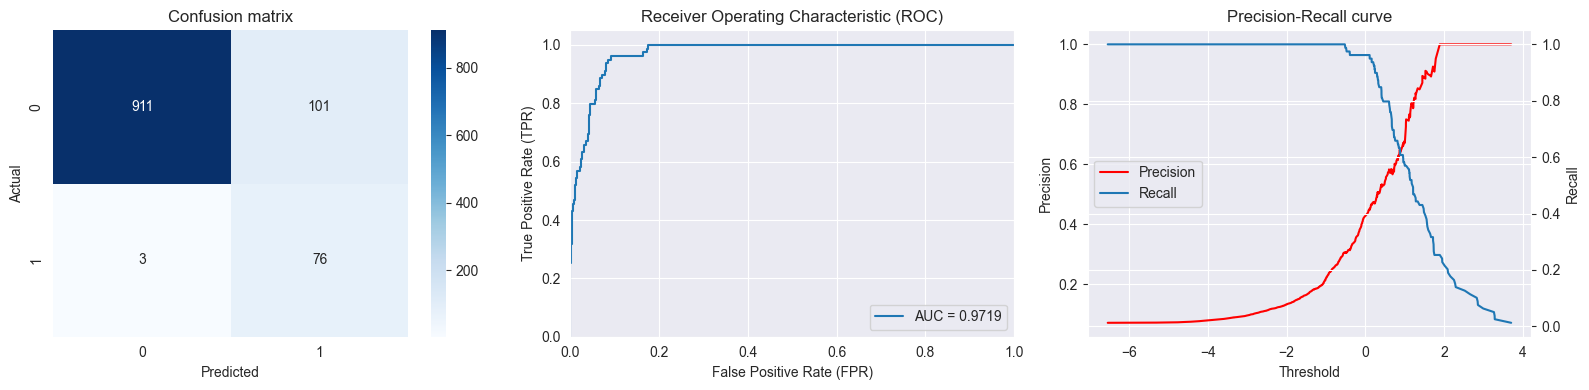

accuracy score 0.9047
precision score 0.4294
recall score 0.9620
f1 score 0.5938
AUC = 0.9719
average precision score 0.7573


In [14]:
y_baseline, y_baseline_score, model_baseline= svc_model(X_train, X_test, y_train)
compute_performance(y_test, y_baseline, y_baseline_score)

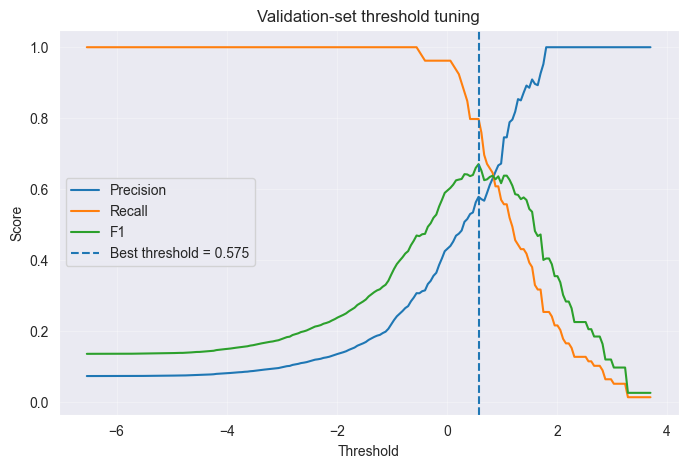

Best SMOTE validation threshold: 0.575


,threshold,accuracy,precision,recall,f1
139,0.5753,0.9432,0.5780,0.7975,0.6702
138,0.5241,0.9404,0.5625,0.7975,0.6597
140,0.6265,0.9413,0.5714,0.7595,0.6522
134,0.3193,0.9294,0.5074,0.8734,0.6419
135,0.3705,0.9313,0.5154,0.8481,0.6411


In [40]:
best_threshold, threshold_table = find_best_threshold(y_test, y_baseline_score)
print("Best SMOTE validation threshold:", round(best_threshold, 3))
threshold_table.sort_values("f1", ascending=False).head()

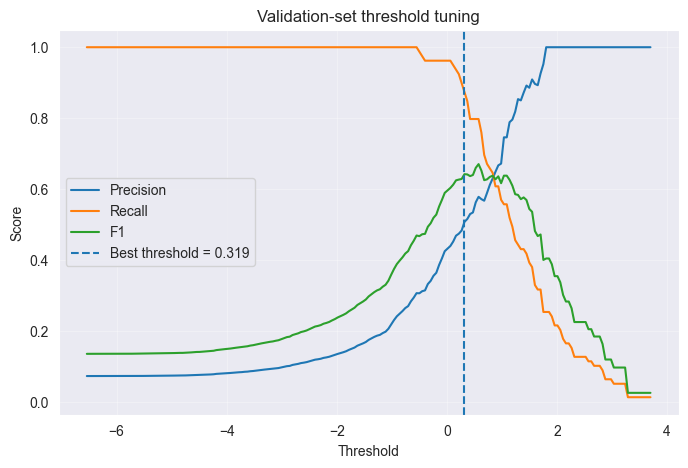

Best SMOTE validation threshold: 0.319


,threshold,accuracy,precision,recall,f1
134,0.3193,0.9294,0.5074,0.8734,0.6419
133,0.2681,0.9230,0.4830,0.8987,0.6283
132,0.2169,0.9203,0.4740,0.9241,0.6266
131,0.1657,0.9184,0.4684,0.9367,0.6245
130,0.1145,0.9129,0.4518,0.9494,0.6122


In [41]:
best_threshold, threshold_table = find_best_threshold(y_test, y_baseline_score, floor_level=0.85)
print("Best SMOTE validation threshold:", round(best_threshold, 3))
threshold_table.sort_values("f1", ascending=False).head()

# 7. model2: SMOTE+default parameters
even for the default model, the performance is not poor except for the precision rate.

SMOTE is applied to mitigate imbalance, and improvement is expected.

- model2: applying the SMOTE to mitigate imbalance, using default parameters

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy= 0.5, random_state=42, k_neighbors=4)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(X_train.shape, y_train.shape)
print(X_train_resampled.shape, y_train_resampled.shape)
print(y_train.sum(), y_train_resampled.sum())


(4360, 35) (4360,)
(6069, 35) (6069,)
314 2023


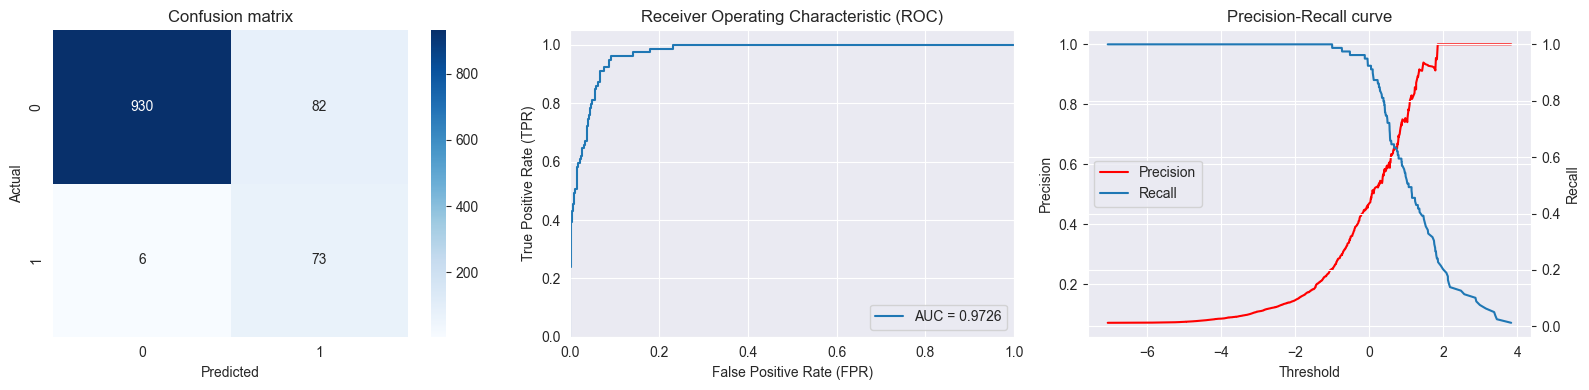

accuracy score 0.9193
precision score 0.4710
recall score 0.9241
f1 score 0.6239
AUC = 0.9726
average precision score 0.7660


In [16]:
y_baseline2, y_baseline2_score, model_baseline2 = svc_model(X_train_resampled, X_test, y_train_resampled)
compute_performance(y_test, y_baseline2, y_baseline2_score)

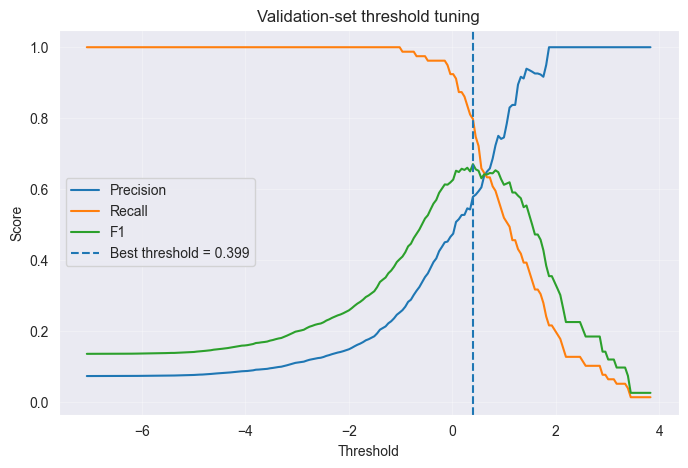

Best SMOTE validation threshold: 0.399


,threshold,accuracy,precision,recall,f1
137,0.3991,0.9432,0.5780,0.7975,0.6702
135,0.2901,0.9377,0.5455,0.8354,0.6600
133,0.1812,0.9340,0.5267,0.8734,0.6571
138,0.4536,0.9432,0.5842,0.7468,0.6556
134,0.2357,0.9340,0.5271,0.8608,0.6538


In [42]:
best_threshold, threshold_table = find_best_threshold(y_test, y_baseline2_score)
print("Best SMOTE validation threshold:", round(best_threshold, 3))
threshold_table.sort_values("f1", ascending=False).head()

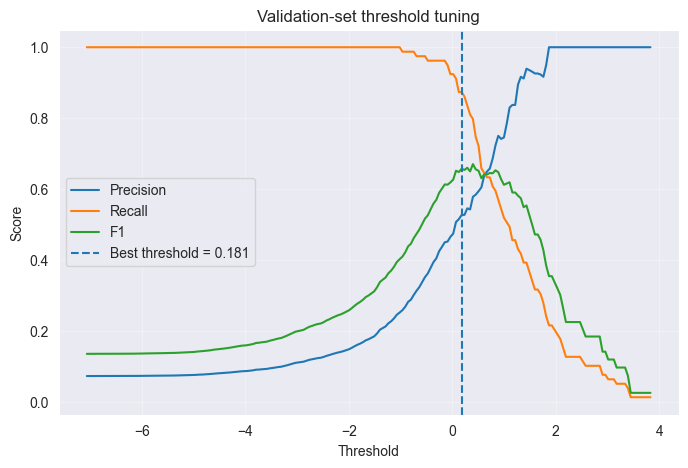

Best SMOTE validation threshold: 0.181


,threshold,accuracy,precision,recall,f1
133,0.1812,0.9340,0.5267,0.8734,0.6571
134,0.2357,0.9340,0.5271,0.8608,0.6538
131,0.0722,0.9294,0.5070,0.9114,0.6516
132,0.1267,0.9313,0.5149,0.8734,0.6479
130,0.0178,0.9203,0.4740,0.9241,0.6266


In [43]:
best_threshold, threshold_table = find_best_threshold(y_test, y_baseline2_score, floor_level=0.85)
print("Best SMOTE validation threshold:", round(best_threshold, 3))
threshold_table.sort_values("f1", ascending=False).head()

# 8. model 3:SMOTE + grid search(optimizing by f1 score)

While the recall rate drops about 3%, f1 score rises from 58% to 63% and precision rate is improved by 6%.
This result shows that SMOTE is useful for imbalanced data.

If we are expected to strike a balance between recall rate(correctly predict a planet suitable for human habitalization) and precision rate (measure the cost of excluding inaccurate prediction), grid search optimizing f1 score can be implemented to achieve a trade-off.


- model3: use grid search to find a model gain a maximum f1 score

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline


pipeline = Pipeline([
    # unlike the model2, SMOTE is applied inside the pipeline
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(class_weight='balanced', random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'smote__sampling_strategy': [0.3, 0.5],
    'smote__k_neighbors': [4, 5],
    'svc__C':      [0.1, 0.5, 1, 5],
    'svc__kernel': ['rbf', 'poly', 'sigmoid'],
    'svc__gamma':  ['scale', 'auto', 0.01, 0.1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv = cv,
    scoring = 'f1',
    n_jobs = -1
)

grid.fit(X_train, y_train)
grid.best_params_


{'smote__k_neighbors': 4,
 'smote__sampling_strategy': 0.5,
 'svc__C': 5,
 'svc__gamma': 'auto',
 'svc__kernel': 'rbf'}

In [18]:
print(f'best CV F1 score in training set: {grid.best_score_:.4f}')

best CV F1 score in training set: 0.6934


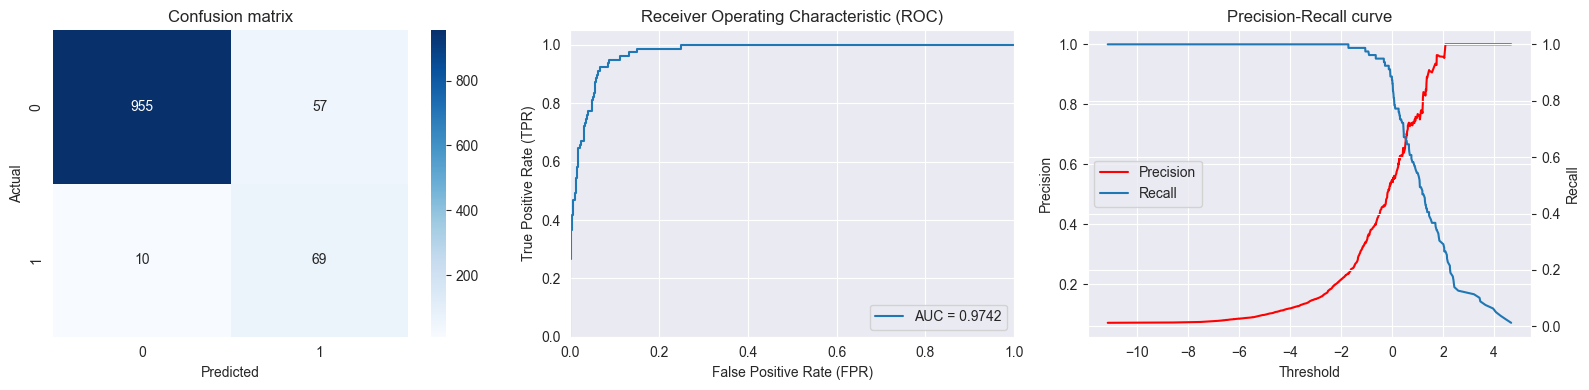

accuracy score 0.9386
precision score 0.5476
recall score 0.8734
f1 score 0.6732
AUC = 0.9742
average precision score 0.7780


In [19]:
model_best = grid.best_estimator_
y_best = model_best.predict(X_test)
y_best_score = model_best.decision_function(X_test)
compute_performance(y_test, y_best, y_best_score)

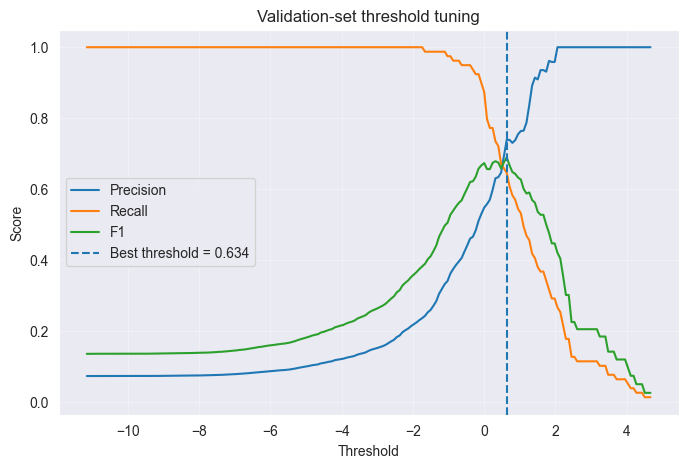

Best SMOTE validation threshold: 0.634


,threshold,accuracy,precision,recall,f1
149,0.634431,0.957837,0.739130,0.645570,0.689189
145,0.317866,0.949588,0.630435,0.734177,0.678363
148,0.555290,0.954170,0.693333,0.658228,0.675325
146,0.397008,0.949588,0.633333,0.721519,0.674556
144,0.238725,0.945921,0.598039,0.772152,0.674033


In [33]:
best_threshold, threshold_table = find_best_threshold(y_test, y_best_score)
print("Best SMOTE validation threshold:", round(best_threshold, 3))
threshold_table.sort_values("f1", ascending=False).head()

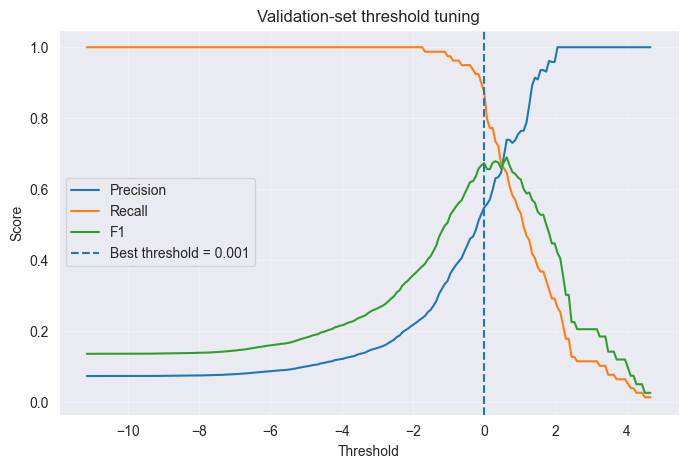

Best SMOTE validation threshold: 0.001


,threshold,accuracy,precision,recall,f1
141,0.001302,0.938588,0.547619,0.873418,0.673171
140,-0.077840,0.934922,0.529851,0.898734,0.666667
139,-0.156981,0.930339,0.510490,0.924051,0.657658
138,-0.236122,0.923006,0.483444,0.924051,0.634783
137,-0.315263,0.917507,0.465409,0.936709,0.621849


In [34]:
best_threshold, threshold_table = find_best_threshold(y_test, y_best_score, floor_level=0.85)
print("Best SMOTE validation threshold:", round(best_threshold, 3))
threshold_table.sort_values("f1", ascending=False).head()

F1 score difference between train set and test set is small than 5%, indicating less likely to be overfitted

recall rate drops to 87%, approximately 10% lower, and precision score is improved by 10%.

AUC of the three models are around 97%, this may be due to imbalanced frequency, average precision rate could be a more valuable indicator instead.

If necessary, I can do the threshold tuning to find the threshold(rather than default value 0) that maximises f1 score or satisfies a recall >90% constraint.

# 9. permutation importance

In [17]:
from sklearn.inspection import permutation_importance

def permutation_plot(model, X_test, y_test, feature_name):
    result = permutation_importance(model, X_test, y_test,
                                    n_repeats=30, scoring='f1', random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'feature': feature_name,
        'importance': result.importances_mean,
        'std': result.importances_std
    }).sort_values('importance', ascending=False)

    top = perm_df.head(10)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(top['feature'], top['importance'], xerr=top['std'])
    ax.set_xlabel('Mean decrease in F1')
    ax.set_title('Permutation Importance (Top 10 Features)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


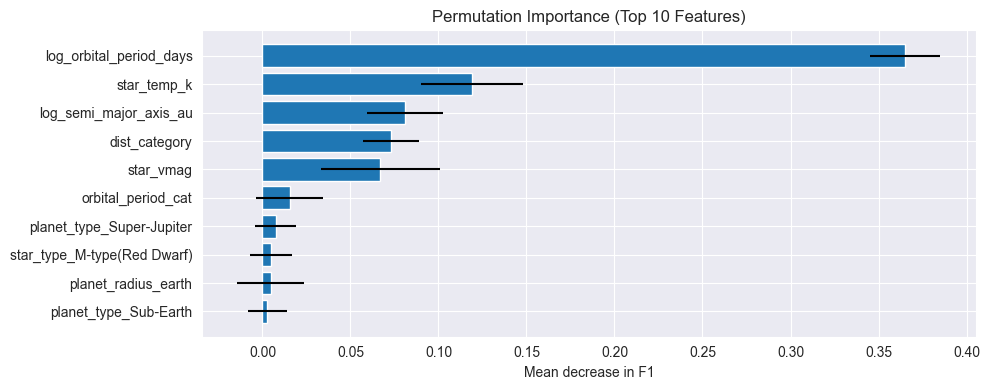

In [21]:
permutation_plot(model_best, X_test, y_test, cols)

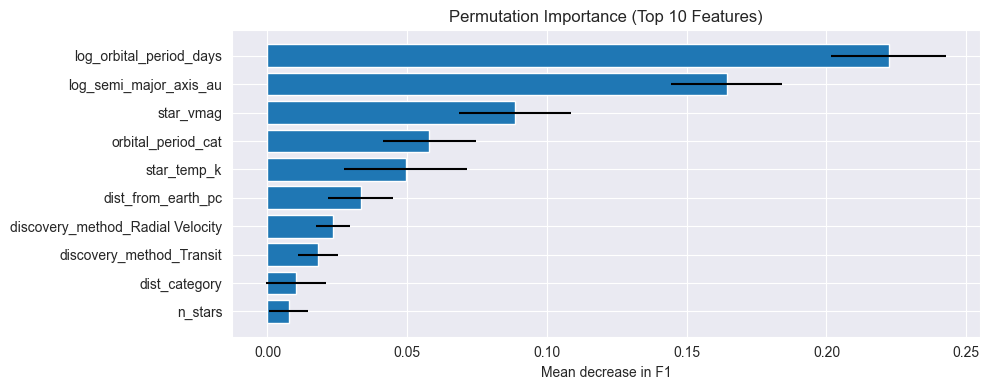

In [22]:
permutation_plot(model_baseline, X_test, y_test, cols)

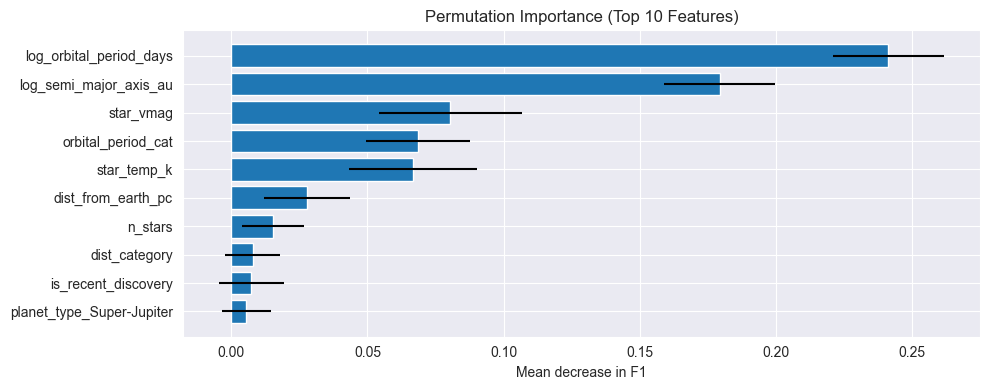

In [18]:
permutation_plot(model_baseline2, X_test, y_test, cols)

considering the features that have a distinct impact(>0.05) on the f1 score, the baseline model and the model3 align with the observation that orbital period, semi major axis, star_vmag and star temperature are effective indicators.


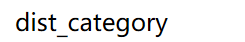